# Supervised learning på svensk turismdata kombinerad med väderdata

Frågeställning: Kan vädervariabler hjälpa till att förklara variationer i turism?

Hypotes:
- Alla regioner tillsammans ger svag signal.
- Sommarregioner under sommarmånader bör ge tydligare vädersignal.
- Region och historiska nivåer är sannolikt starkare än väder.
- Träningsmodellen blir kass

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
from pathlib import Path

DATA_PATH = Path("data/final_tourist_data.csv")

df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,year,guest_nights,region,month,date,occupancy_rate,guest_lag1,guest_lag2,guest_lag12,occ_lag1,...,rain_mean,occupancy_rate_total,occupancy_vs_total,sunny_days,mean_sun_hours,total_sun_hours,eur,usd,nok,dkk
0,2016,899950,dalarna,7,2016-07-01,0.651423,294049.0,157406.0,815341.0,0.382347,...,3.393548,0.689116,-0.037693,20,9.234400,286.266389,9.47149,8.56058,1.01087,1.27321
1,2016,551055,norrbotten,7,2016-07-01,0.543563,213093.0,129740.0,516109.0,0.406692,...,3.696774,0.689116,-0.145553,23,10.175735,315.447778,9.47149,8.56058,1.01087,1.27321
2,2016,375313,vasterbotten,7,2016-07-01,0.577188,156829.0,110225.0,351895.0,0.482250,...,2.651613,0.689116,-0.111928,24,9.903790,307.017500,9.47149,8.56058,1.01087,1.27321
3,2016,377219,jamtland,7,2016-07-01,0.582445,129819.0,67308.0,342708.0,0.367817,...,2.267742,0.689116,-0.106671,21,9.321828,288.976667,9.47149,8.56058,1.01087,1.27321
4,2016,266737,vasternorrland,7,2016-07-01,0.575731,116763.0,83850.0,264611.0,0.453449,...,1.341935,0.689116,-0.113385,27,9.220194,285.826007,9.47149,8.56058,1.01087,1.27321


In [5]:
df.shape

(1028, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  1028 non-null   int64  
 1   guest_nights          1028 non-null   int64  
 2   region                1028 non-null   object 
 3   month                 1028 non-null   int64  
 4   date                  1028 non-null   object 
 5   occupancy_rate        1028 non-null   float64
 6   guest_lag1            1028 non-null   float64
 7   guest_lag2            1028 non-null   float64
 8   guest_lag12           1028 non-null   float64
 9   occ_lag1              1028 non-null   float64
 10  temp_mean             1028 non-null   float64
 11  rain_sum              1028 non-null   float64
 12  rain_days             1028 non-null   float64
 13  rain_mean             1028 non-null   float64
 14  occupancy_rate_total  1028 non-null   float64
 15  occupancy_vs_total   

Datasetet innehåller turism per region och månad, med guest_nights (gästnätter från tillväxtverket) som huvudvariabel. 
Det finns även vädervariabler som temperatur, regn och sol samt lag-features från tidigare månader/år från SMHIs olika mätstationer för våra utvalda regioner.

In [7]:
df["log_guest_nights"] = np.log(df["guest_nights"])

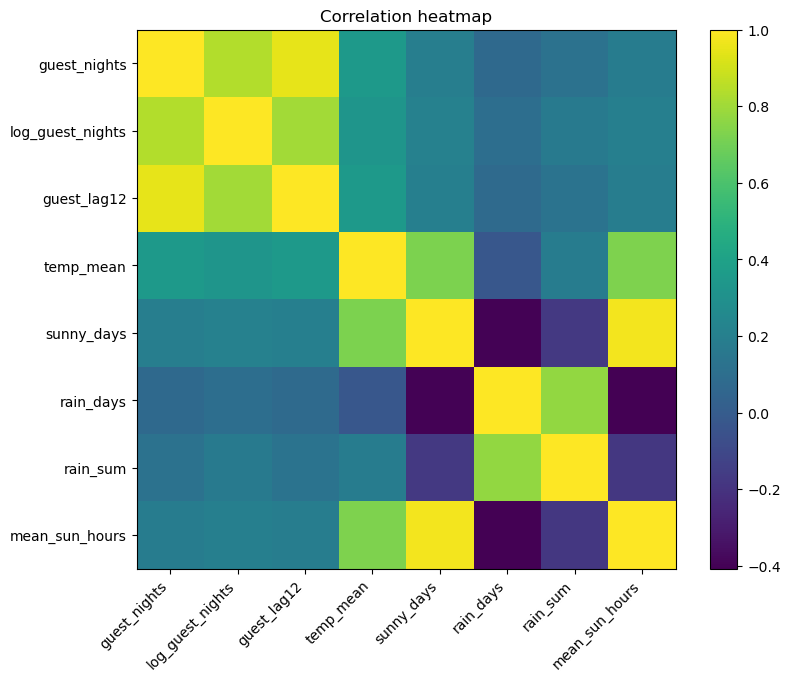

In [8]:
corr_features = [
    "guest_nights",
    "log_guest_nights",
    "guest_lag12",
    "temp_mean",
    "sunny_days",
    "rain_days",
    "rain_sum",
    "mean_sun_hours"
]

corr = df[corr_features].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap")
plt.show()

Heatmapen visar att guest_lag12 (förra årets värde) har starkast samband med guest_nights. Det är logiskt eftersom turismnivåer ofta liknar samma månad föregående år. Vädervariablerna visar svagare samband, vilket gör regression relevant för att testa om flera vädervariabler tillsammans kan bidra med signal.

# Linjär regression – alla regioner

Först testades en enkel linjär regressionsmodell på alla regioner samtidigt för att undersöka om vädervariabler kunde förklara variationer i turism.

In [9]:
import statsmodels.api as sm

In [10]:
features = [
    "temp_mean",
    "sunny_days",
    "rain_days"
]

X = df[features]

y = df["log_guest_nights"]

In [11]:
X = sm.add_constant(X)

In [12]:
model = sm.OLS(y, X).fit()

In [13]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_guest_nights   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     46.35
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.35e-28
Time:                        01:11:55   Log-Likelihood:                -1519.8
No. Observations:                1028   AIC:                             3048.
Df Residuals:                    1024   BIC:                             3067.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6811      0.125     93.471      0.0

När alla regioner analyserades tillsammans kunde vädervariablerna förklara ungefär 12% av variationen i turismnivåer.

Temperatur visade ett positivt och statistiskt signifikant samband med turism, medan vissa andra vädervariabler blev instabila eller svårtolkade, sannolikt på grund av korrelation mellan vädervariablerna och stora regionala skillnader.

# Modellförbättring – fokus på sommarregioner

Eftersom alla regioner tillsammans gav relativt svaga samband testades modellen även på regioner där väder rimligen borde spela större roll för turismen.

In [14]:
summer_regions = [
    "gotland",
    "stockholm",
    "vastragotaland"
]

summer_df = df[
    df["region"].isin(summer_regions)
].copy()

In [15]:
summer_df = summer_df[
    summer_df["month"].isin([6, 7, 8])
].copy()

In [16]:
summer_df.shape

(87, 24)

In [17]:
candidate_features = [
    "temp_mean",
    "sunny_days",
    "mean_sun_hours",
    "total_sun_hours",
    "rain_days",
    "rain_sum",
    "rain_mean",
    "eur",
    "usd",
    "nok",
    "dkk"
]

In [18]:
import itertools
import pandas as pd
import statsmodels.api as sm

results = []

max_features = 4

for n in range(1, max_features + 1):

    for combo in itertools.combinations(candidate_features, n):

        features = list(combo)

        X = summer_df[features]

        X = sm.add_constant(X)

        y = summer_df["log_guest_nights"]

        model = sm.OLS(y, X).fit()

        results.append({
            "features": ", ".join(features),
            "r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
            "aic": model.aic
        })

results_df = pd.DataFrame(results)

In [19]:
results_df.sort_values(
    by="adj_r2",
    ascending=False
).head(10)

,features,r2,adj_r2,aic
67,"temp_mean, sunny_days, total_sun_hours",0.332634,0.308512,213.720359
240,"temp_mean, sunny_days, total_sun_hours, rain_sum",0.340444,0.308271,214.696159
241,"temp_mean, sunny_days, total_sun_hours, rain_mean",0.339770,0.307564,214.785030
66,"temp_mean, sunny_days, mean_sun_hours",0.330652,0.306459,213.978354
233,"temp_mean, sunny_days, mean_sun_hours, rain_sum",0.338645,0.306383,214.933235
234,"temp_mean, sunny_days, mean_sun_hours, rain_mean",0.337919,0.305622,215.028661
231,"temp_mean, sunny_days, mean_sun_hours, total_s...",0.336891,0.304545,215.163568
243,"temp_mean, sunny_days, total_sun_hours, usd",0.334427,0.301960,215.486346
239,"temp_mean, sunny_days, total_sun_hours, rain_days",0.333726,0.301225,215.577884
11,"temp_mean, sunny_days",0.317142,0.300883,213.716864


När modellen begränsades till sommarregioner och flera vädervariabler kombinerades ökade modellens förklaringsgrad från cirka R² ≈ 0.12 till omkring R² ≈ 0.33.

Adjusted R² användes eftersom vanligt R² nästan alltid ökar när fler variabler läggs till. Adjusted R² straffar onödigt komplexa modeller och gör jämförelsen mellan feature-kombinationer mer rättvis.

De mest användbara variablerna var temperatur, soldagar och soltimmar. Valutavariabler och ytterligare regnvariabler gav endast marginella förbättringar.

Det antyder att väder verkar bidra med viss signal för sommarturism, men att sambanden fortfarande är relativt svaga och brusiga.

In [20]:
best_features = [
    "temp_mean",
    "sunny_days",
    "total_sun_hours"
]

In [21]:
X = summer_df[best_features]

y = summer_df["log_guest_nights"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

In [25]:
train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", round(train_r2, 3))

print("Test R²:", round(test_r2, 3))

Train R²: 0.387
Test R²: -0.067


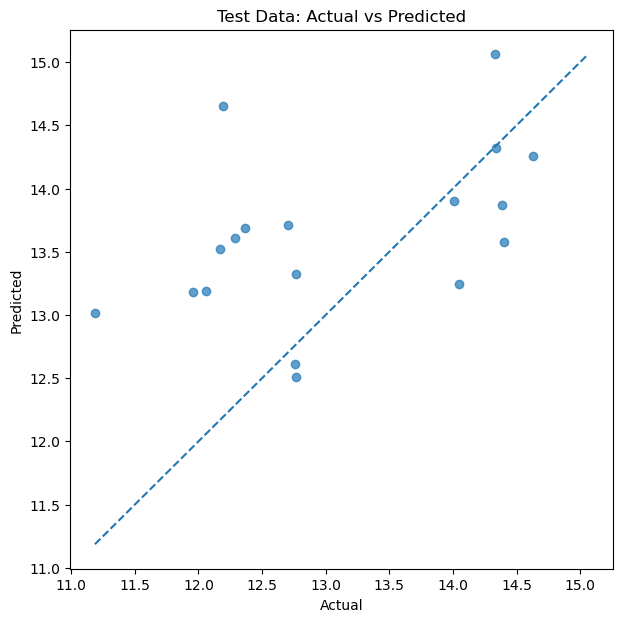

In [26]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Test Data: Actual vs Predicted")

plt.show()

Modellen kunde hitta vissa samband i träningsdatan, men sambanden generaliserade svagt till ny data. Det visar svårigheten med att modellera verklig turismdata där många faktorer utöver väder påverkar utfallet.

In [27]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

print("RMSE:", round(rmse, 3))

RMSE: 1.086


Vi kunde identifiera vissa samband mellan väder och turism, särskilt för sommarregioner, men modellerna generaliserade relativt dåligt på ny data. Det visar hur svårt det är att bygga robusta prediktionsmodeller på komplex samhällsdata med många externa faktorer och begränsat antal observationer.

För att jämföra med ett mer klassiskt machine learning-problem kommer vi också visa ett Telco-dataset där signalerna är tydligare och modellerna presterar betydligt bättre